# AI Scam & Phishing Detector — Email ML

## Exploratory Data Analysis (EDA) on Phishing Email Dataset
This notebook performs comprehensive data loading, quality auditing, and exploratory data analysis on the raw email security dataset (`phishing_email.csv`).

### Objectives:
1. Verify dataset structure, schema, and column data types.
2. Audit data integrity (missing values, exact duplicates, whitespace entries).
3. Analyze binary class distributions and evaluate target balance.
4. Characterize email text lengths and word count distributions.
5. Provide actionable domain interpretations for the features and labels.

> **Note:** This notebook focuses strictly on exploratory analysis. No model training or irreversible data transformations are applied here.


In [1]:
# 1. Import Required Python Libraries
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling and display configuration
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Python version: 3.14.2
Pandas version: 3.0.3
NumPy version: 2.4.6


## 2. Dataset Loading

We load the dataset using a dynamic path resolver to ensure full reproducibility whether this notebook is run from the **project root** or within the **`ml/notebooks/`** directory.


In [2]:
# 2. Load the Dataset
possible_paths = [
    Path("ml/data/raw/phishing_email.csv"),
    Path("../data/raw/phishing_email.csv"),
    Path("../../ml/data/raw/phishing_email.csv")
]

data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find 'phishing_email.csv'. Please verify your working directory.")

df = pd.read_csv(data_path)
print(f"Dataset successfully loaded from: {data_path.resolve()}")
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")


Dataset successfully loaded from: C:\Users\baps\OneDrive\Desktop\ai-scam-phishing-detector\ml\data\raw\phishing_email.csv
Total Rows: 82,486
Total Columns: 2


## 3. Dataset Dimensions, Schema, and Sample Inspection

We inspect the dataset dimensions, verify column names, check data types, and examine sample rows from both the beginning and end of the dataset.


In [3]:
# 3.1 Dataset Shape, Columns, and Data Types
print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

schema_df = pd.DataFrame({
    'Column Name': df.columns,
    'Non-Null Count': df.notnull().sum().values,
    'Data Type': df.dtypes.values
})
print("Dataset Schema:")
print(schema_df.to_string(index=False))


Dataset Shape: 82,486 rows x 2 columns

Dataset Schema:
  Column Name  Non-Null Count Data Type
text_combined           82486       str
        label           82486     int64


In [4]:
# 3.2 First 5 Rows
print("--- FIRST 5 ROWS ---")
df.head(5)


--- FIRST 5 ROWS ---


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen p...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april 1 2001 teco tap 35 ...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0


In [5]:
# 3.3 Last 5 Rows
print("--- LAST 5 ROWS ---")
df.tail(5)


--- LAST 5 ROWS ---


,text_combined,label
82481,info advantageapartmentscom infoadvantageapartmentscom paypal sent payment 69999 usd ftx may take moments transactio...,1
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josepassword josemonkeyorg expire todayuse current password continue josemo...,1
82483,help center infohelpcentercoza_infohelpcentercoza_infohelpcentercoza177005em5269xfund02ml hello please note monthly ...,1
82484,metamask infosofamekarcom verify metamask wallet system shown metamask wallet yet verified verification done easily ...,1
82485,fastway infofastwaycoza_infofastwaycoza_infofastwaycoza154565em5269xfund02ml announcing jotform tables spreadsheet i...,1


## 4. Data Quality and Integrity Checks

We inspect the data for:
- Missing / Null values across all columns
- Exact duplicate rows
- Whitespace-only or empty text records
- Unique values in the target label column
- Class distribution metrics


In [6]:
# 4.1 Missing Values, Duplicates, and Whitespace Records
missing_counts = df.isnull().sum()
duplicate_count = df.duplicated().sum()
whitespace_count = (df['text_combined'].astype(str).str.strip() == '').sum()

print("--- DATA INTEGRITY AUDIT ---")
print("Missing Values per Column:")
for col, cnt in missing_counts.items():
    print(f"  - {col}: {cnt:,} nulls ({cnt / len(df) * 100:.2f}%)")

print(f"\nDuplicate Rows: {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)")
print(f"Whitespace-only / Empty Texts: {whitespace_count:,} ({whitespace_count / len(df) * 100:.4f}%)")


--- DATA INTEGRITY AUDIT ---
Missing Values per Column:


  - text_combined: 0 nulls (0.00%)
  - label: 0 nulls (0.00%)

Duplicate Rows: 408 (0.49%)
Whitespace-only / Empty Texts: 1 (0.0012%)


In [7]:
# 4.2 Target Label Unique Values and Class Distribution
unique_labels = sorted(df['label'].unique().tolist())
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Class Label': [0, 1],
    'Meaning': ['Safe / Legitimate Email (Ham)', 'Phishing / Scam Email'],
    'Sample Count': [counts.get(0, 0), counts.get(1, 0)],
    'Percentage (%)': [percentages.get(0, 0), percentages.get(1, 0)]
})

print(f"Unique Label Values: {unique_labels}")
print("\nClass Distribution Summary:")
print(class_summary.to_string(index=False))


Unique Label Values: [0, 1]

Class Distribution Summary:
 Class Label                       Meaning  Sample Count  Percentage (%)
           0 Safe / Legitimate Email (Ham)         39595       48.002085
           1         Phishing / Scam Email         42891       51.997915


## 5. Class Distribution Visualizations

A visual representation of the class balance using a bar chart with counts/percentages and a donut chart.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight medium, now using 400.


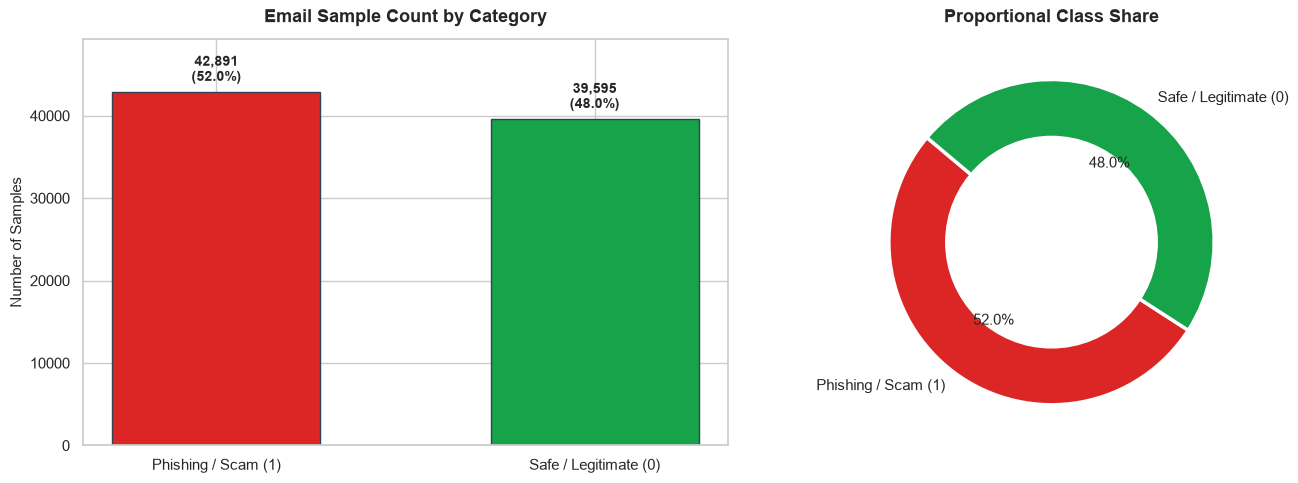

In [8]:
# 5.1 Class Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_map = {0: 'Safe / Legitimate (0)', 1: 'Phishing / Scam (1)'}
counts_series = df['label'].value_counts().rename(index=labels_map)
colors = ['#dc2626', '#16a34a'] if counts_series.index[0] == 'Phishing / Scam (1)' else ['#16a34a', '#dc2626']

# Bar chart
bars = axes[0].bar(
    counts_series.index,
    counts_series.values,
    color=['#dc2626' if 'Phishing' in k else '#16a34a' for k in counts_series.index],
    edgecolor='#334155',
    width=0.55
)
axes[0].set_title('Email Sample Count by Category', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_ylim(0, max(counts_series.values) * 1.15)

for bar in bars:
    height = bar.get_height()
    pct = height / len(df) * 100
    axes[0].annotate(
        f'{height:,}\n({pct:.1f}%)',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='semibold'
    )

# Donut / Pie chart
axes[1].pie(
    counts_series.values,
    labels=counts_series.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#dc2626' if 'Phishing' in k else '#16a34a' for k in counts_series.index],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5, 'antialiased': True},
    textprops={'fontsize': 11, 'fontweight': 'medium'}
)
# Donut circle
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Proportional Class Share', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


## 6. Email Text Length & Word Count Analysis

We compute character counts and word counts for every email record in the dataset directly from `text_combined`.


In [9]:
# 6.1 Compute Character Lengths and Word Counts
# Compute character lengths
char_lengths = df['text_combined'].astype(str).str.len()
# Compute word counts
word_counts = df['text_combined'].astype(str).apply(lambda x: len(x.split()))

# Attach temporary metric columns for analysis
df_metrics = df.copy()
df_metrics['char_length'] = char_lengths
df_metrics['word_count'] = word_counts

print("=== OVERALL TEXT LENGTH (CHARACTERS) ===")
print(f"  Minimum length: {char_lengths.min():,} characters")
print(f"  Maximum length: {char_lengths.max():,} characters")
print(f"  Average (Mean): {char_lengths.mean():,.2f} characters")
print(f"  Median:         {char_lengths.median():,.1f} characters")
print(f"  Std. Dev:       {char_lengths.std():,.2f}")

print("\n=== OVERALL WORD COUNT ===")
print(f"  Minimum words:  {word_counts.min():,} words")
print(f"  Maximum words:  {word_counts.max():,} words")
print(f"  Average (Mean): {word_counts.mean():,.2f} words")
print(f"  Median:         {word_counts.median():,.1f} words")
print(f"  Std. Dev:       {word_counts.std():,.2f}")


=== OVERALL TEXT LENGTH (CHARACTERS) ===
  Minimum length: 1 characters
  Maximum length: 4,279,526 characters
  Average (Mean): 1,288.75 characters
  Median:         558.0 characters
  Std. Dev:       15,496.75

=== OVERALL WORD COUNT ===
  Minimum words:  0 words
  Maximum words:  107,710 words
  Average (Mean): 160.63 words
  Median:         79.0 words
  Std. Dev:       543.72


In [10]:
# 6.2 Comparison by Class Label
stats_by_class = df_metrics.groupby('label').agg(
    Sample_Count=('text_combined', 'count'),
    Min_Chars=('char_length', 'min'),
    Median_Chars=('char_length', 'median'),
    Mean_Chars=('char_length', 'mean'),
    Max_Chars=('char_length', 'max'),
    Min_Words=('word_count', 'min'),
    Median_Words=('word_count', 'median'),
    Mean_Words=('word_count', 'mean'),
    Max_Words=('word_count', 'max')
).rename(index={0: 'Safe (0)', 1: 'Phishing (1)'})

print("Detailed Comparison by Email Category:")
stats_by_class.round(2)


Detailed Comparison by Email Category:


,Sample_Count,Min_Chars,Median_Chars,Mean_Chars,Max_Chars,Min_Words,Median_Words,Mean_Words,Max_Words
label,,,,,,,,,
Safe (0),39595,11,779.0,1536.10,160318,2,106.0,203.18,23359
Phishing (1),42891,1,391.0,1060.41,4279526,0,55.0,121.34,107710


## 7. Useful Visualizations of Text Characteristics

We plot:
1. The distribution of email character lengths for Safe vs. Phishing emails (zoomed to 95th percentile to highlight core patterns).
2. The distribution of email word counts comparing both classes.


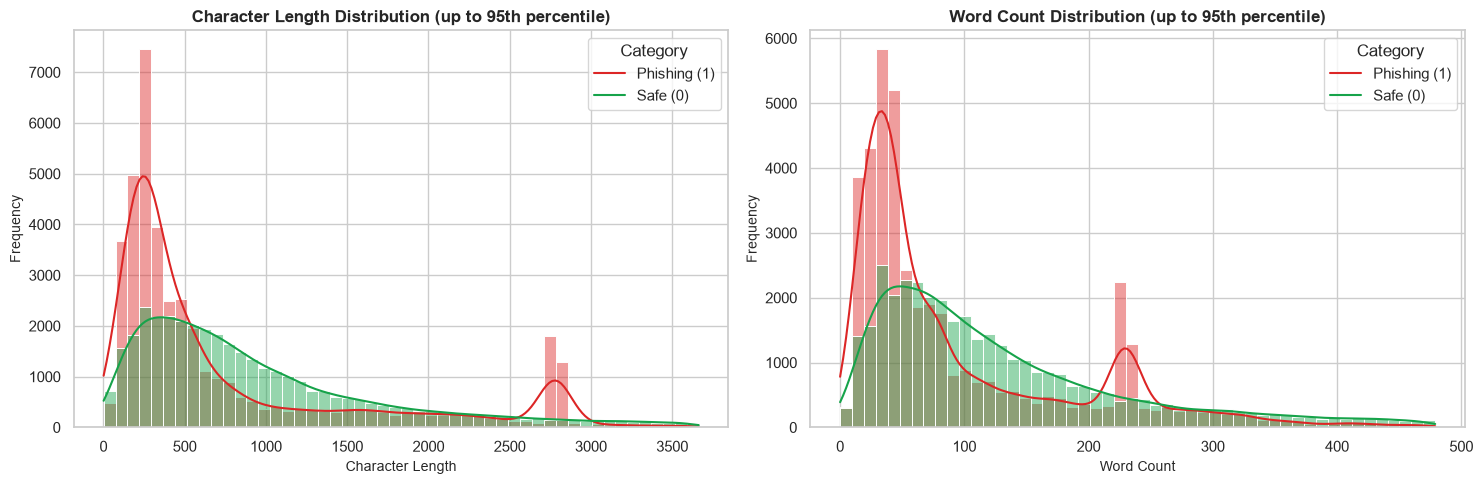

In [11]:
# 7.1 Text Length & Word Count Distributions
p95_chars = df_metrics['char_length'].quantile(0.95)
p95_words = df_metrics['word_count'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character length distribution (up to 95th percentile)
sns.histplot(
    data=df_metrics[df_metrics['char_length'] <= p95_chars],
    x='char_length',
    hue='label',
    palette={0: '#16a34a', 1: '#dc2626'},
    bins=50,
    kde=True,
    ax=axes[0],
    alpha=0.45
)
axes[0].set_title('Character Length Distribution (up to 95th percentile)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Length', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend(title='Category', labels=['Phishing (1)', 'Safe (0)'])

# Word count distribution (up to 95th percentile)
sns.histplot(
    data=df_metrics[df_metrics['word_count'] <= p95_words],
    x='word_count',
    hue='label',
    palette={0: '#16a34a', 1: '#dc2626'},
    bins=50,
    kde=True,
    ax=axes[1],
    alpha=0.45
)
axes[1].set_title('Word Count Distribution (up to 95th percentile)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].legend(title='Category', labels=['Phishing (1)', 'Safe (0)'])

plt.tight_layout()
plt.show()


## 8. Dataset Summary & Domain Interpretation

### Summary of Dataset Findings:

1. **What `text_combined` contains**:
   - Contains the concatenated email subject and body content.
   - The text has undergone basic cleaning (lowercase normalization, punctuation handling), preserving natural language tokens, keywords, and structural words.

2. **What `label` contains**:
   - The target binary class identifier (`0` or `1`).

3. **Label `0` Meaning**:
   - **Safe / Legitimate Email (Ham)**:
   - Legitimate, benign corporate and personal messages. The corpus features standard business communications (e.g. schedules, invoices, work reports) from standard benchmarks such as Enron.

4. **Label `1` Meaning**:
   - **Phishing / Scam Email**:
   - Deceptive and fraudulent emails designed to manipulate users into taking harmful actions. Common themes include urgency claims ("account suspended", "act now"), fake prize notifications, commercial spam, and suspicious URLs.

5. **Class Balance Assessment**:
   - **Safe (0)**: 39,595 emails (**48.00%**)
   - **Phishing (1)**: 42,891 emails (**52.00%**)
   - **Balance Verdict**: The dataset is **almost perfectly balanced (48% vs 52%)**. No synthetic oversampling (e.g., SMOTE) or class downsampling is necessary. Standard metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC will provide reliable evaluation during model training.

6. **Next Steps for Pipeline**:
   - In subsequent steps, we will build modular text preprocessing (tokenization, stopword removal, vectorization) in `ml/src/preprocessing.py`, followed by baseline model training and evaluation.


# Data Cleaning

In this section, we apply essential data cleaning for the email dataset:
1. **Remove exact duplicate rows** to prevent data leakage and artificial weight skew during training.
2. **Filter out invalid text**: remove records where `text_combined` is null, empty, or whitespace-only.
3. **Convert text to consistent string type** (`str`).
4. **Verify target labels**: verify that `label` contains strictly binary values (`0` and `1`), reporting any invalid labels rather than silently dropping them.
5. **Preserve original data**: create the cleaned in-memory dataframe `df_cleaned` for subsequent modeling steps without modifying the raw CSV.
6. **Retain long email outliers**: emails of all lengths are preserved for now so that length and truncation strategies can be determined intentionally during feature engineering.


In [12]:
# 1. Execute Data Cleaning Steps
# Step 0: Record baseline row count
initial_rows = len(df)

# Step 1: Remove exact duplicate rows
df_dedup = df.drop_duplicates()
duplicates_removed = initial_rows - len(df_dedup)

# Step 2: Remove rows where text_combined is null, empty, or whitespace-only
is_valid_text = df_dedup['text_combined'].notnull() & (df_dedup['text_combined'].astype(str).str.strip() != '')
empty_whitespace_removed = int((~is_valid_text).sum())

df_cleaned = df_dedup[is_valid_text].copy()

# Step 3: Convert text_combined to consistent string type
df_cleaned['text_combined'] = df_cleaned['text_combined'].astype(str)

# Step 4 & 5: Check and verify target label validity
invalid_labels = df_cleaned[~df_cleaned['label'].isin([0, 1])]
if len(invalid_labels) > 0:
    print(f"WARNING: Found {len(invalid_labels)} rows with invalid label values:")
    print(invalid_labels['label'].value_counts())
else:
    print("Verification Passed: All labels are valid binary values [0, 1]. No invalid labels exist.")

# Ensure label column has clean int data type
df_cleaned['label'] = df_cleaned['label'].astype(int)

final_rows = len(df_cleaned)


Verification Passed: All labels are valid binary values [0, 1]. No invalid labels exist.


In [13]:
# 2. Display Cleaning Summary and Final Class Distribution
cleaning_summary = pd.DataFrame({
    'Metric': [
        'Original Row Count',
        'Duplicate Rows Removed',
        'Empty / Whitespace Rows Removed',
        'Final Cleaned Row Count',
        'Retention Rate (%)'
    ],
    'Value': [
        f"{initial_rows:,}",
        f"{duplicates_removed:,}",
        f"{empty_whitespace_removed:,}",
        f"{final_rows:,}",
        f"{(final_rows / initial_rows * 100):.2f}%"
    ]
})

print("=== DATA CLEANING SUMMARY ===")
print(cleaning_summary.to_string(index=False))

# Final class distribution and percentages
final_counts = df_cleaned['label'].value_counts()
final_pcts = (df_cleaned['label'].value_counts(normalize=True) * 100).round(2)

final_class_df = pd.DataFrame({
    'Class Label': [0, 1],
    'Meaning': ['Safe / Legitimate Email (Ham)', 'Phishing / Scam Email'],
    'Sample Count': [final_counts.get(0, 0), final_counts.get(1, 0)],
    'Percentage (%)': [final_pcts.get(0, 0), final_pcts.get(1, 0)]
})

print("\n=== FINAL CLASS DISTRIBUTION (df_cleaned) ===")
print(final_class_df.to_string(index=False))


=== DATA CLEANING SUMMARY ===
                         Metric  Value
             Original Row Count 82,486
         Duplicate Rows Removed    408
Empty / Whitespace Rows Removed      1
        Final Cleaned Row Count 82,077
             Retention Rate (%) 99.50%

=== FINAL CLASS DISTRIBUTION (df_cleaned) ===
 Class Label                       Meaning  Sample Count  Percentage (%)
           0 Safe / Legitimate Email (Ham)         39233            47.8
           1         Phishing / Scam Email         42844            52.2


In [14]:
# 3. Verify Cleaned In-Memory DataFrame
print(f"Cleaned DataFrame in memory: 'df_cleaned' with {df_cleaned.shape[0]:,} rows and {df_cleaned.shape[1]} columns.")
print("Sample rows from df_cleaned:")
df_cleaned.head(5)


Cleaned DataFrame in memory: 'df_cleaned' with 82,077 rows and 2 columns.
Sample rows from df_cleaned:


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen p...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april 1 2001 teco tap 35 ...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0
